# Monte Carlo & Synthetic-Market Robustness Suite
**Strategies:** `bitcoin_crash_strategy.py` (BTC) and `eth_final_strategy.py` (ETH) — run exactly as written, with their frozen parameters, 0.15 % cost per side and 5 % short carry.

| Part | Test | Question it answers |
|---|---|---|
| **A** | Monte Carlo — **trade resampling** | How much of the historical result is luck in *which trades happened* and *in what order*? |
| **B** | Monte Carlo — **parameter perturbation** | Does the edge survive if every parameter is a bit "wrong"? (overfitting check) |
| **C** | **Synthetic market test** — `trend_bull`, `momentum_mild`, `bubble_burst`, `chop_low_vol` | How does the strategy behave in market regimes it was not tuned on? |

**How to use:** put this notebook in the same folder as the 2 `.py` files and 2 `.csv` files, then run the cells **top to bottom, one at a time** (Shift+Enter). Every cell prints its table and/or draws its charts. All knobs are in **Cell 1**.

## Setup

In [1]:
import importlib.util, subprocess, sys, time, warnings
from dataclasses import replace
from pathlib import Path

try:
    import numba
except ImportError:
    print("numba not found -> installing ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "numba"])
    import numba

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from IPython.display import display

warnings.filterwarnings("ignore")

DATA_DIR       = Path(".")
ASSETS         = ["BTC", "ETH"]
SEED           = 26
INITIAL        = 100_000.0

N_TRADE_SIMS   = 5000
BLOCK          = 5
SKIP_FRAC      = 0.15

N_PARAM_RUNS   = 150
PERTURB_PCT    = 0.20

N_SYNTH_PATHS  = 20
SYNTH_DAYS     = 1095

OUT_DIR = Path("mc_results"); OUT_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
C_STRAT, C_BH, C_BASE, C_BAD = "#1f77b4", "#7f7f7f", "#ff7f0e", "#d62728"
print("Settings loaded. numba", numba.__version__)

Settings loaded. numba 0.68.0


In [2]:
def load_module(name, fname):
    p = DATA_DIR / fname
    if not p.exists():
        raise FileNotFoundError(f"{p.resolve()} not found - put the notebook next to your .py/.csv files or edit DATA_DIR")
    spec = importlib.util.spec_from_file_location(name, p)
    mod = importlib.util.module_from_spec(spec); sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

btc_mod = load_module("btc_strat", "bitcoin_crash_strategy.py")
eth_mod = load_module("eth_strat", "eth_final_strategy.py")

%matplotlib inline

SPEC = {
    "BTC": dict(mod=btc_mod, csv="BTCUSDT.csv", cfg=btc_mod.Config(**btc_mod.FROZEN_PARAMETERS)),
    "ETH": dict(mod=eth_mod, csv="ETHUSDT.csv", cfg=eth_mod.Config(**eth_mod.FROZEN_PARAMETERS)),
}
SPEC = {a: SPEC[a] for a in ASSETS}
print("Strategy modules loaded for:", list(SPEC))

Strategy modules loaded for: ['BTC', 'ETH']


BTC: 175,296 bars  2021-01-01 -> 2025-12-31   (4.3s)   audit ok: True


ETH: 175,296 bars  2021-01-01 -> 2025-12-31   (3.3s)   audit ok: True


,total_return_pct,cagr_pct,sharpe,max_dd_pct,trades,short_trades,win_rate_pct
BTC strategy,733.00,52.81,1.72,23.59,64.0,19.0,82.81
BTC buy&hold,203.03,24.83,0.67,77.23,NaN,NaN,NaN
ETH strategy,1154.58,65.86,1.46,24.51,122.0,57.0,57.38
ETH buy&hold,303.53,32.19,0.75,81.46,NaN,NaN,NaN


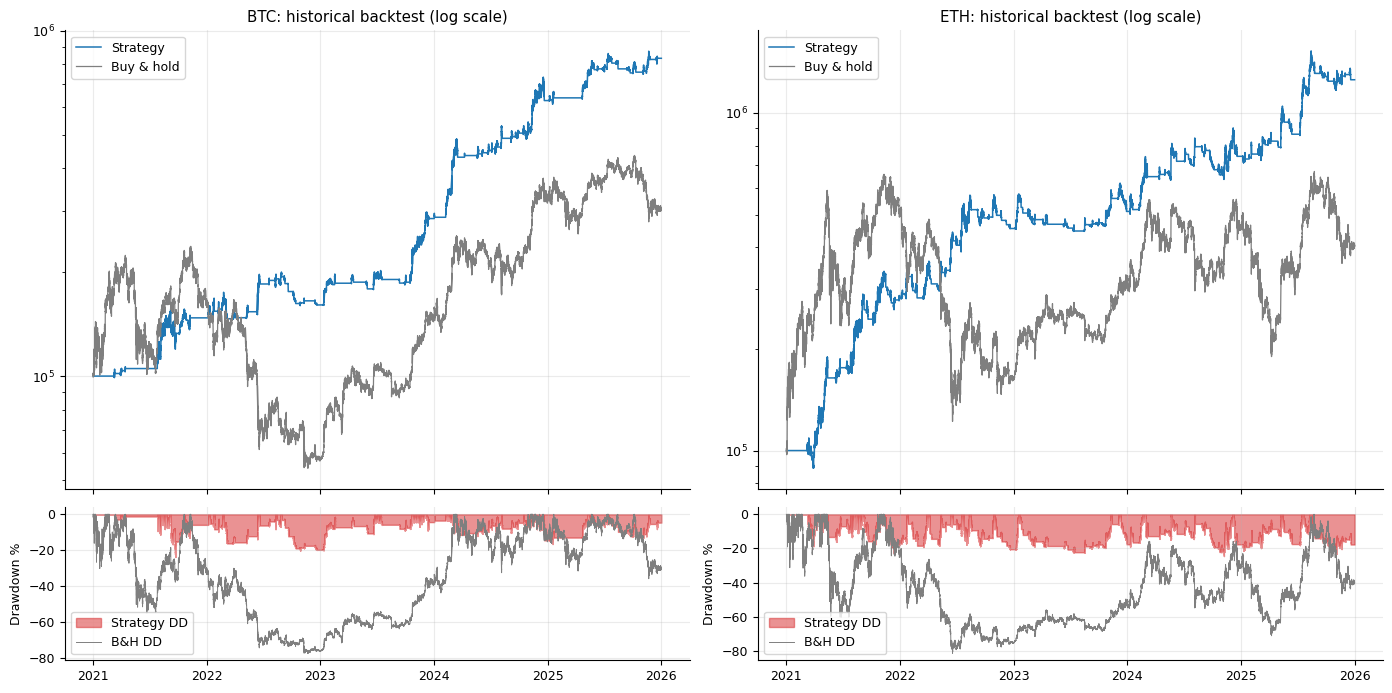

In [3]:
def equity_metrics(eq, initial=INITIAL):
    """Return / CAGR / Sharpe / max-DD from a 15-min equity series (same daily-Sharpe convention as the strategy files)."""
    eq = eq.dropna()
    daily = eq.resample("1D").last().dropna()
    r = daily.pct_change().dropna()
    days = max((eq.index[-1] - eq.index[0]).total_seconds() / 86400, 1)
    peak = np.maximum.accumulate(np.r_[initial, eq.to_numpy()])[1:]
    final = eq.iloc[-1]
    return dict(total_return_pct=100 * (final / initial - 1),
                cagr_pct=100 * ((max(final, 1e-9) / initial) ** (365.25 / days) - 1),
                sharpe=float(np.sqrt(365) * r.mean() / r.std(ddof=1)) if r.std() > 0 else 0.0,
                max_dd_pct=float(100 * (1 - eq.to_numpy() / peak).max()))

def bh_curve(d, idx, initial=INITIAL):
    return initial * d.close.reindex(idx) / d.open.reindex(idx).iloc[0]

def run_strategy(a, d=None, cfg=None, features=None, start=None, end=None):
    s = SPEC[a]; d = s["d"] if d is None else d
    return s["mod"].run(d, s["cfg"] if cfg is None else cfg, features=features, start=start, end=end)

rows = {}
for a, s in SPEC.items():
    t0 = time.time()
    s["d"] = s["mod"].load_data(DATA_DIR / s["csv"])
    s["F"] = s["mod"].Features(s["d"])
    s["path"], s["fills"], s["tr"], s["audit"] = run_strategy(a, features=s["F"])
    s["bh"] = bh_curve(s["d"], s["path"].index)
    m, b = equity_metrics(s["path"].equity), equity_metrics(s["bh"])
    rows[f"{a} strategy"] = {**m, "trades": len(s["tr"]), "short_trades": int((s["tr"].direction < 0).sum()),
                             "win_rate_pct": 100 * (s["tr"].pnl > 0).mean()}
    rows[f"{a} buy&hold"] = b
    print(f"{a}: {len(s['d']):,} bars  {s['d'].index[0].date()} -> {s['d'].index[-1].date()}   ({time.time()-t0:.1f}s)   audit ok: "
          f"{s['audit']['gap_cap_breaches']==0 and s['audit']['intrabar_cap_breaches']==0}")
baseline = pd.DataFrame(rows).T
display(baseline.round(2))

fig, axes = plt.subplots(2, len(SPEC), figsize=(7 * len(SPEC), 7), sharex="col", squeeze=False,
                         gridspec_kw={"height_ratios": [3, 1]})
for j, (a, s) in enumerate(SPEC.items()):
    eq = s["path"].equity
    axes[0, j].plot(eq, color=C_STRAT, lw=1.1, label="Strategy"); axes[0, j].plot(s["bh"], color=C_BH, lw=.9, label="Buy & hold")
    axes[0, j].set_yscale("log"); axes[0, j].set_title(f"{a}: historical backtest (log scale)"); axes[0, j].legend()
    axes[1, j].fill_between(eq.index, -100 * (1 - eq / eq.cummax()), 0, color=C_BAD, alpha=.5, label="Strategy DD")
    axes[1, j].plot(-100 * (1 - s["bh"] / s["bh"].cummax()), color=C_BH, lw=.7, label="B&H DD")
    axes[1, j].set_ylabel("Drawdown %"); axes[1, j].legend(loc="lower left")
plt.tight_layout(); plt.show()

---
## Part A — Monte Carlo: trade resampling
Take the strategy's actual closed trades, convert each to a **return on the equity it was opened with**, and re-draw the sequence thousands of times:
* **Bootstrap** – sample trades with replacement (different mix of winners/losers)
* **Shuffle** – same trades, random order (isolates *sequence* risk → drawdown)
* **Block bootstrap** – bootstrap in blocks of `BLOCK` trades (keeps streaks / clustering)
* **Skip 15 %** – bootstrap, then randomly miss `SKIP_FRAC` of trades (missed fills / downtime)

In [4]:
def trade_returns(tr, initial=INITIAL):
    """pnl / equity-at-entry. The strategy is flat between trades, so entry equity = initial + all earlier pnl."""
    pnl = tr.pnl.to_numpy()
    return pnl / (initial + np.r_[0.0, np.cumsum(pnl)[:-1]])

dep_rows = {}
for a, s in SPEC.items():
    s["r"] = trade_returns(s["tr"])
    chk = INITIAL * np.prod(1 + s["r"])
    assert abs(chk - s["path"].equity.iloc[-1]) < 1.0, "trade-return reconstruction does not match final equity"
    srt = np.sort(s["r"])[::-1]
    dep = {"all trades": 100 * (np.prod(1 + s["r"]) - 1)}
    for k in (1, 3, 5):
        dep[f"without best {k}"] = 100 * (np.prod(1 + srt[k:]) - 1)
    dep_rows[a] = dep
    print(f"{a}: {len(s['r'])} trades | mean {100*s['r'].mean():.2f}% | median {100*np.median(s['r']):.2f}% | "
          f"best {100*s['r'].max():.1f}% | worst {100*s['r'].min():.1f}% | win-rate {100*(s['r']>0).mean():.0f}%")
print("\nTotal return (%) after removing the best N trades  -> how fragile is the edge to a few outliers?")
display(pd.DataFrame(dep_rows).T.round(1))

BTC: 64 trades | mean 3.81% | median 1.08% | best 52.9% | worst -9.8% | win-rate 83%
ETH: 122 trades | mean 2.50% | median 0.64% | best 50.1% | worst -6.4% | win-rate 57%

Total return (%) after removing the best N trades  -> how fragile is the edge to a few outliers?


,all trades,without best 1,without best 3,without best 5
BTC,733.0,444.9,188.7,98.8
ETH,1154.6,735.8,354.6,161.5


In [5]:
METHODS = ["Bootstrap", "Shuffle", "Block bootstrap", f"Skip {int(SKIP_FRAC*100)}%"]

def resample_trades(r, method, n_sims, rng):
    n = len(r)
    if method == "Shuffle":
        idx = np.argsort(rng.random((n_sims, n)), axis=1); return r[idx]
    if method == "Block bootstrap":
        nb = int(np.ceil(n / BLOCK)); st = rng.integers(0, n, (n_sims, nb))
        idx = ((st[:, :, None] + np.arange(BLOCK)) % n).reshape(n_sims, -1)[:, :n]; return r[idx]
    rr = r[rng.integers(0, n, (n_sims, n))]
    if method.startswith("Skip"):
        rr = np.where(rng.random(rr.shape) < SKIP_FRAC, 0.0, rr)
    return rr

def path_stats(rr):
    eq = INITIAL * np.cumprod(1 + rr, axis=1)
    eqf = np.concatenate([np.full((len(rr), 1), INITIAL), eq], axis=1)
    dd = 1 - eqf / np.maximum.accumulate(eqf, axis=1)
    return eqf, eq[:, -1] / INITIAL - 1, dd.max(axis=1)

rng = np.random.default_rng(SEED)
tables = {}
for a, s in SPEC.items():
    s["mc"] = {}
    for m in METHODS:
        rr = resample_trades(s["r"], m, N_TRADE_SIMS, rng)
        s["mc"][m] = path_stats(rr)
    _, orig_ret, orig_dd = path_stats(s["r"][None, :])
    rows = {"Actual (trade-close basis)": dict(median_ret=100*orig_ret[0], p5_ret=np.nan, p95_ret=np.nan, prob_loss=np.nan,
                                              median_dd=100*orig_dd[0], p95_dd=np.nan, p_dd_gt30=np.nan, p_dd_gt50=np.nan)}
    for m, (eqf, ret, dd) in s["mc"].items():
        rows[m] = dict(median_ret=100*np.median(ret), p5_ret=100*np.percentile(ret, 5), p95_ret=100*np.percentile(ret, 95),
                       prob_loss=100*(ret < 0).mean(), median_dd=100*np.median(dd), p95_dd=100*np.percentile(dd, 95),
                       p_dd_gt30=100*(dd > .30).mean(), p_dd_gt50=100*(dd > .50).mean())
    tables[a] = pd.DataFrame(rows).T
    s["mc_orig"] = (orig_ret[0], orig_dd[0])
    print(f"\n{a} — {N_TRADE_SIMS:,} simulated sequences per method  (all numbers in %)")
    display(tables[a].round(1))
pd.concat(tables, names=["asset"]).to_csv(OUT_DIR / "A_trade_resampling.csv")


BTC — 5,000 simulated sequences per method  (all numbers in %)


,median_ret,p5_ret,p95_ret,prob_loss,median_dd,p95_dd,p_dd_gt30,p_dd_gt50
Actual (trade-close basis),733.0,NaN,NaN,NaN,17.1,NaN,NaN,NaN
Bootstrap,695.0,177.2,2666.2,0.0,11.6,21.7,0.5,0.0
Shuffle,733.0,733.0,733.0,0.0,12.2,18.8,0.0,0.0
Block bootstrap,691.1,153.6,3092.5,0.1,15.1,26.9,2.5,0.0
Skip 15%,470.1,116.9,1831.9,0.0,11.0,20.5,0.4,0.0



ETH — 5,000 simulated sequences per method  (all numbers in %)


,median_ret,p5_ret,p95_ret,prob_loss,median_dd,p95_dd,p_dd_gt30,p_dd_gt50
Actual (trade-close basis),1154.6,NaN,NaN,NaN,19.4,NaN,NaN,NaN
Bootstrap,1126.3,170.5,6469.9,0.2,28.1,44.6,40.6,2.0
Shuffle,1154.6,1154.6,1154.6,0.0,27.3,40.2,34.9,0.4
Block bootstrap,1127.1,246.0,5044.6,0.0,22.8,35.6,15.0,0.2
Skip 15%,714.4,104.1,3701.1,0.5,26.7,43.3,34.9,1.7


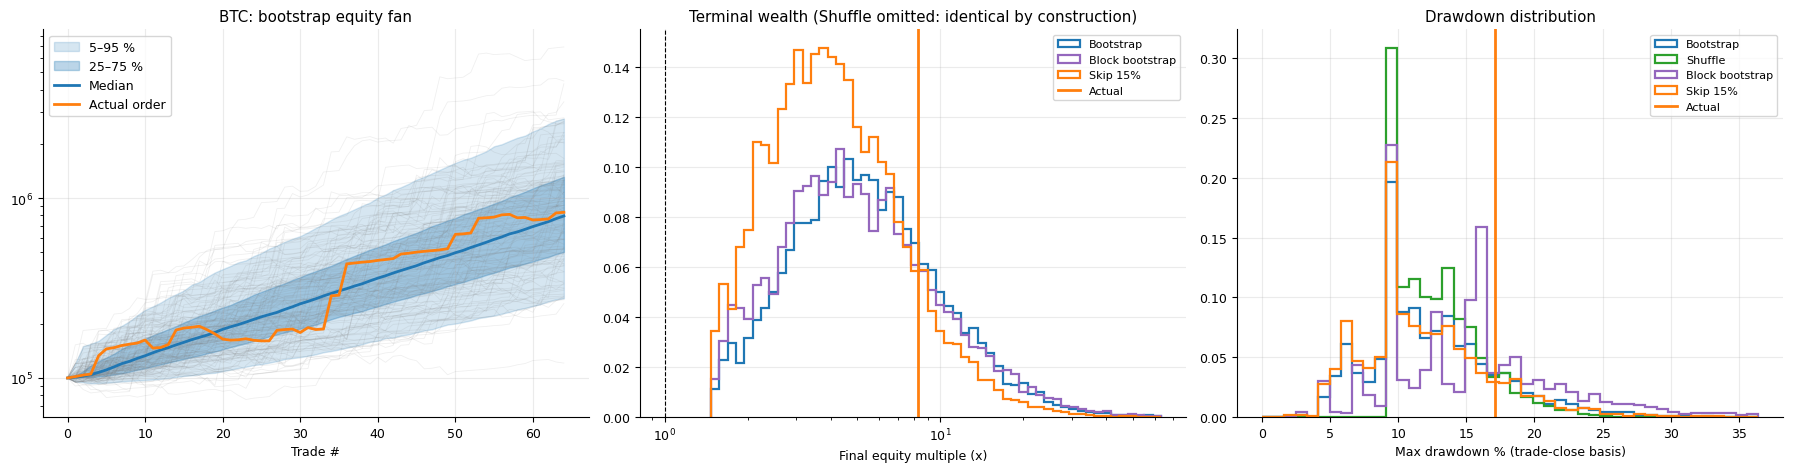

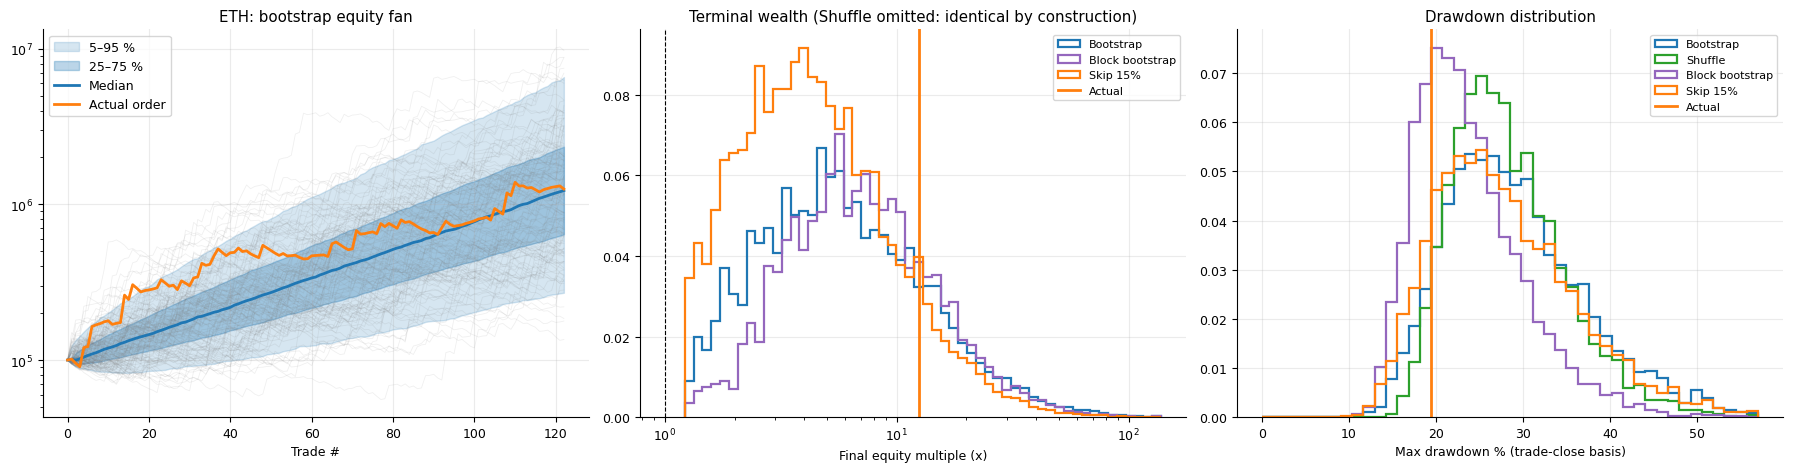

In [6]:
mcol = dict(zip(METHODS, ["#1f77b4", "#2ca02c", "#9467bd", "#ff7f0e"]))
for a, s in SPEC.items():
    fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
    eqf = s["mc"]["Bootstrap"][0]; x = np.arange(eqf.shape[1])
    for p in eqf[:120]: ax[0].plot(x, p, color="grey", alpha=.12, lw=.6)
    ax[0].fill_between(x, *np.percentile(eqf, [5, 95], axis=0), color=C_STRAT, alpha=.18, label="5–95 %")
    ax[0].fill_between(x, *np.percentile(eqf, [25, 75], axis=0), color=C_STRAT, alpha=.30, label="25–75 %")
    ax[0].plot(x, np.median(eqf, axis=0), color=C_STRAT, lw=2, label="Median")
    ax[0].plot(INITIAL * np.r_[1, np.cumprod(1 + s["r"])], color=C_BASE, lw=2, label="Actual order")
    ax[0].set_yscale("log"); ax[0].set_xlabel("Trade #"); ax[0].set_title(f"{a}: bootstrap equity fan"); ax[0].legend()

    wealth = {m: v for m, v in s["mc"].items() if m != "Shuffle"}
    allret = np.concatenate([1 + v[1] for v in wealth.values()])
    bins = np.geomspace(np.percentile(allret, .5), np.percentile(allret, 99.5), 55)
    for m, (_, ret, dd) in wealth.items():
        ax[1].hist(1 + ret, bins=bins, histtype="step", lw=1.6, color=mcol[m], label=m, density=True)
    ax[1].axvline(1 + s["mc_orig"][0], color=C_BASE, lw=2, label="Actual"); ax[1].axvline(1, color="k", lw=.8, ls="--")
    ax[1].set_xscale("log"); ax[1].set_xlabel("Final equity multiple (x)"); ax[1].set_title("Terminal wealth (Shuffle omitted: identical by construction)"); ax[1].legend(fontsize=8)

    top = max(np.percentile(v[2], 99.5) for v in s["mc"].values()) * 100
    bins = np.linspace(0, top, 45)
    for m, (_, ret, dd) in s["mc"].items():
        ax[2].hist(100 * dd, bins=bins, histtype="step", lw=1.6, color=mcol[m], label=m, density=True)
    ax[2].axvline(100 * s["mc_orig"][1], color=C_BASE, lw=2, label="Actual")
    ax[2].set_xlabel("Max drawdown % (trade-close basis)"); ax[2].set_title("Drawdown distribution"); ax[2].legend(fontsize=8)
    plt.tight_layout(); plt.show()

**Reading Part A**
* *Shuffle* has the **same** terminal wealth as the actual run by construction — only the drawdown changes. If the actual drawdown sits at the low end of the shuffled distribution, the historical path was luckier than average.
* *Bootstrap* / *Block* / *Skip* show how much the **final return** depends on the specific trades. `prob_loss` and `p5_ret` are the numbers to look at.
* Drawdown is measured on trade-close equity, so it is a little smaller than the intra-trade drawdown of the 15-min backtest.

---
## Part B — Monte Carlo: parameter perturbation
Every run multiplies each tunable parameter by a random factor in **[1 − `PERTURB_PCT`, 1 + `PERTURB_PCT`]** (integers are rounded, disabled features stay disabled, constraints such as `short_cap < 1` and `dd_soft < dd_hard` are enforced) and re-runs the full 2021–2025 backtest. If the frozen parameters sit on a sharp peak, most perturbed runs will be far worse than the baseline.

In [7]:
INT_PARAMS   = ["regime_days", "breakout", "exit_bars", "short_breakout", "short_exit",
                "short_regime_days", "short_slope_days", "cooldown_bars"]
FLOAT_PARAMS = ["stop_atr", "lock_trigger", "lock_profit", "trail_atr", "vol_rank_max", "vol_target",
                "short_cap", "short_stop", "short_lock", "short_trail_atr", "short_lock_profit", "short_vol_target",
                "short_hurst_min", "long_adx_min", "short_hysteresis", "dd_soft", "dd_hard"]

def perturb(cfg, rng, pct):
    ch = {}
    for k in INT_PARAMS + FLOAT_PARAMS:
        v = getattr(cfg, k, None)
        if v is None or v <= 0:
            continue
        nv = v * (1 + rng.uniform(-pct, pct))
        ch[k] = max(1, int(round(nv))) if k in INT_PARAMS else float(nv)
    if "vol_rank_max" in ch: ch["vol_rank_max"] = min(ch["vol_rank_max"], 1.0)
    if "short_cap" in ch:    ch["short_cap"] = min(ch["short_cap"], 0.99)
    if "dd_soft" in ch:      ch["dd_soft"] = min(ch["dd_soft"], 0.97)
    if "dd_hard" in ch:      ch["dd_hard"] = min(max(ch["dd_hard"], ch.get("dd_soft", cfg.dd_soft) + 0.01), 0.99)
    return replace(cfg, **ch), {k: ch[k] / getattr(cfg, k) for k in ch}

print("Parameters that will be perturbed (non-zero in the frozen config):")
for a, s in SPEC.items():
    print(f"  {a}:", [k for k in INT_PARAMS + FLOAT_PARAMS if (getattr(s['cfg'], k, 0) or 0) > 0])

Parameters that will be perturbed (non-zero in the frozen config):
  BTC: ['regime_days', 'breakout', 'exit_bars', 'short_breakout', 'short_exit', 'short_regime_days', 'short_slope_days', 'cooldown_bars', 'stop_atr', 'lock_trigger', 'lock_profit', 'vol_rank_max', 'vol_target', 'short_cap', 'short_stop', 'short_lock', 'short_trail_atr', 'short_lock_profit', 'short_vol_target', 'short_hurst_min', 'short_hysteresis', 'dd_soft', 'dd_hard']
  ETH: ['regime_days', 'breakout', 'exit_bars', 'short_breakout', 'short_exit', 'short_slope_days', 'cooldown_bars', 'stop_atr', 'lock_trigger', 'lock_profit', 'trail_atr', 'vol_rank_max', 'vol_target', 'short_cap', 'short_stop', 'short_lock', 'short_trail_atr', 'short_lock_profit', 'long_adx_min', 'dd_soft', 'dd_hard']


In [8]:
rng = np.random.default_rng(SEED + 1)
PARAM = {}
for a, s in SPEC.items():
    rows, curves, t0 = [], {}, time.time()
    base_m = equity_metrics(s["path"].equity)
    rows.append(dict(run=0, kind="baseline", **base_m, trades=len(s["tr"])))
    curves[0] = s["path"].equity.resample("1D").last()
    for i in range(1, N_PARAM_RUNS + 1):
        cfg, mult = perturb(s["cfg"], rng, PERTURB_PCT)
        try:
            path, fills, tr, audit = s["mod"].run(s["d"], cfg, features=s["F"])
            if (path.equity <= 0).any(): raise ValueError("equity <= 0")
            rows.append(dict(run=i, kind="perturbed", **equity_metrics(path.equity), trades=len(tr),
                             **{f"x_{k}": v for k, v in mult.items()}))
            curves[i] = path.equity.resample("1D").last()
        except Exception as e:
            rows.append(dict(run=i, kind="failed", error=str(e)[:80]))
        if i % 25 == 0: print(f"  {a}: {i}/{N_PARAM_RUNS}  ({time.time()-t0:.0f}s)")
    df = pd.DataFrame(rows)
    PARAM[a] = dict(df=df, curves=curves, base=base_m)
    ok = df[df.kind == "perturbed"]
    summ = pd.Series({
        "runs ok": len(ok), "runs failed": int((df.kind == "failed").sum()),
        "baseline return %": base_m["total_return_pct"], "median return %": ok.total_return_pct.median(),
        "5th pct return %": ok.total_return_pct.quantile(.05), "worst return %": ok.total_return_pct.min(),
        "% runs profitable": 100 * (ok.total_return_pct > 0).mean(),
        "% runs beating B&H": 100 * (ok.total_return_pct > equity_metrics(s["bh"])["total_return_pct"]).mean(),
        "baseline Sharpe": base_m["sharpe"], "median Sharpe": ok.sharpe.median(), "5th pct Sharpe": ok.sharpe.quantile(.05),
        "% runs Sharpe >= 70% of baseline": 100 * (ok.sharpe >= .7 * base_m["sharpe"]).mean(),
        "baseline max DD %": base_m["max_dd_pct"], "median max DD %": ok.max_dd_pct.median(), "95th pct max DD %": ok.max_dd_pct.quantile(.95)})
    PARAM[a]["summary"] = summ
    print(f"\n=== {a}: parameter perturbation (+/-{int(PERTURB_PCT*100)} %, {len(ok)} runs) ===")
    display(summ.round(2).to_frame("value"))
    df.to_csv(OUT_DIR / f"B_param_perturbation_{a}.csv", index=False)

  BTC: 25/150  (3s)


  BTC: 50/150  (6s)


  BTC: 75/150  (10s)


  BTC: 100/150  (13s)


  BTC: 125/150  (16s)


...

  ETH: 75/150  (21s)


  ETH: 100/150  (28s)


  ETH: 125/150  (34s)


  ETH: 150/150  (41s)

=== ETH: parameter perturbation (+/-20 %, 150 runs) ===


,value
runs ok,150.00
runs failed,0.00
baseline return %,1154.58
median return %,191.70
5th pct return %,53.20
worst return %,14.60
% runs profitable,100.00
% runs beating B&H,32.00
baseline Sharpe,1.46
median Sharpe,0.86


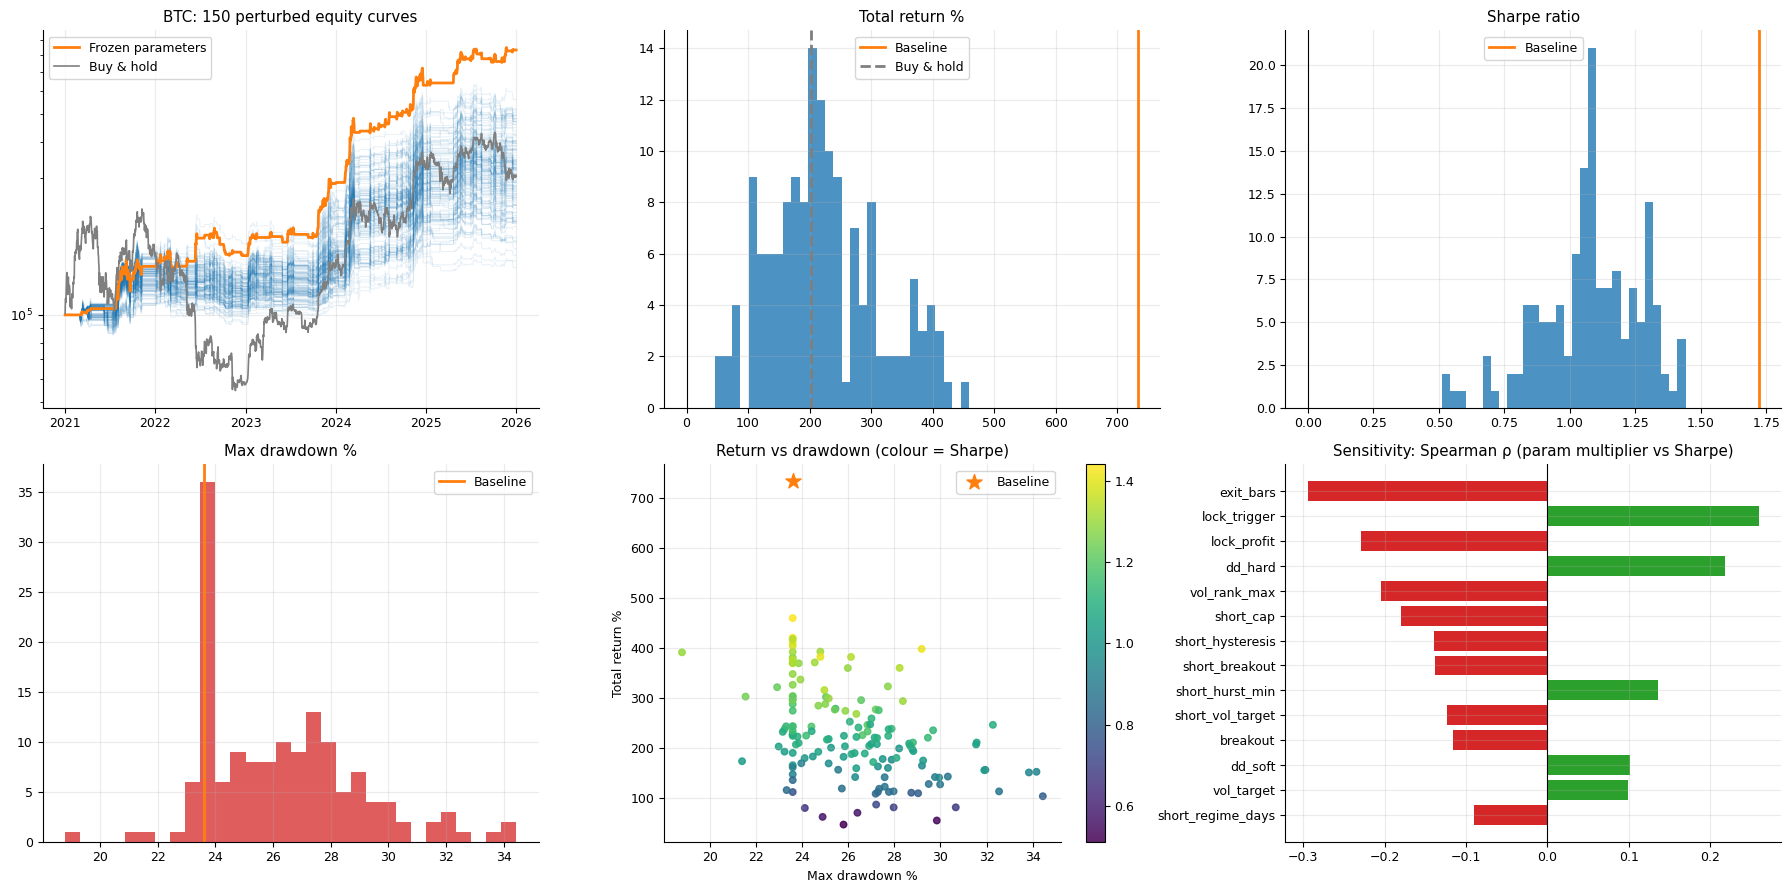

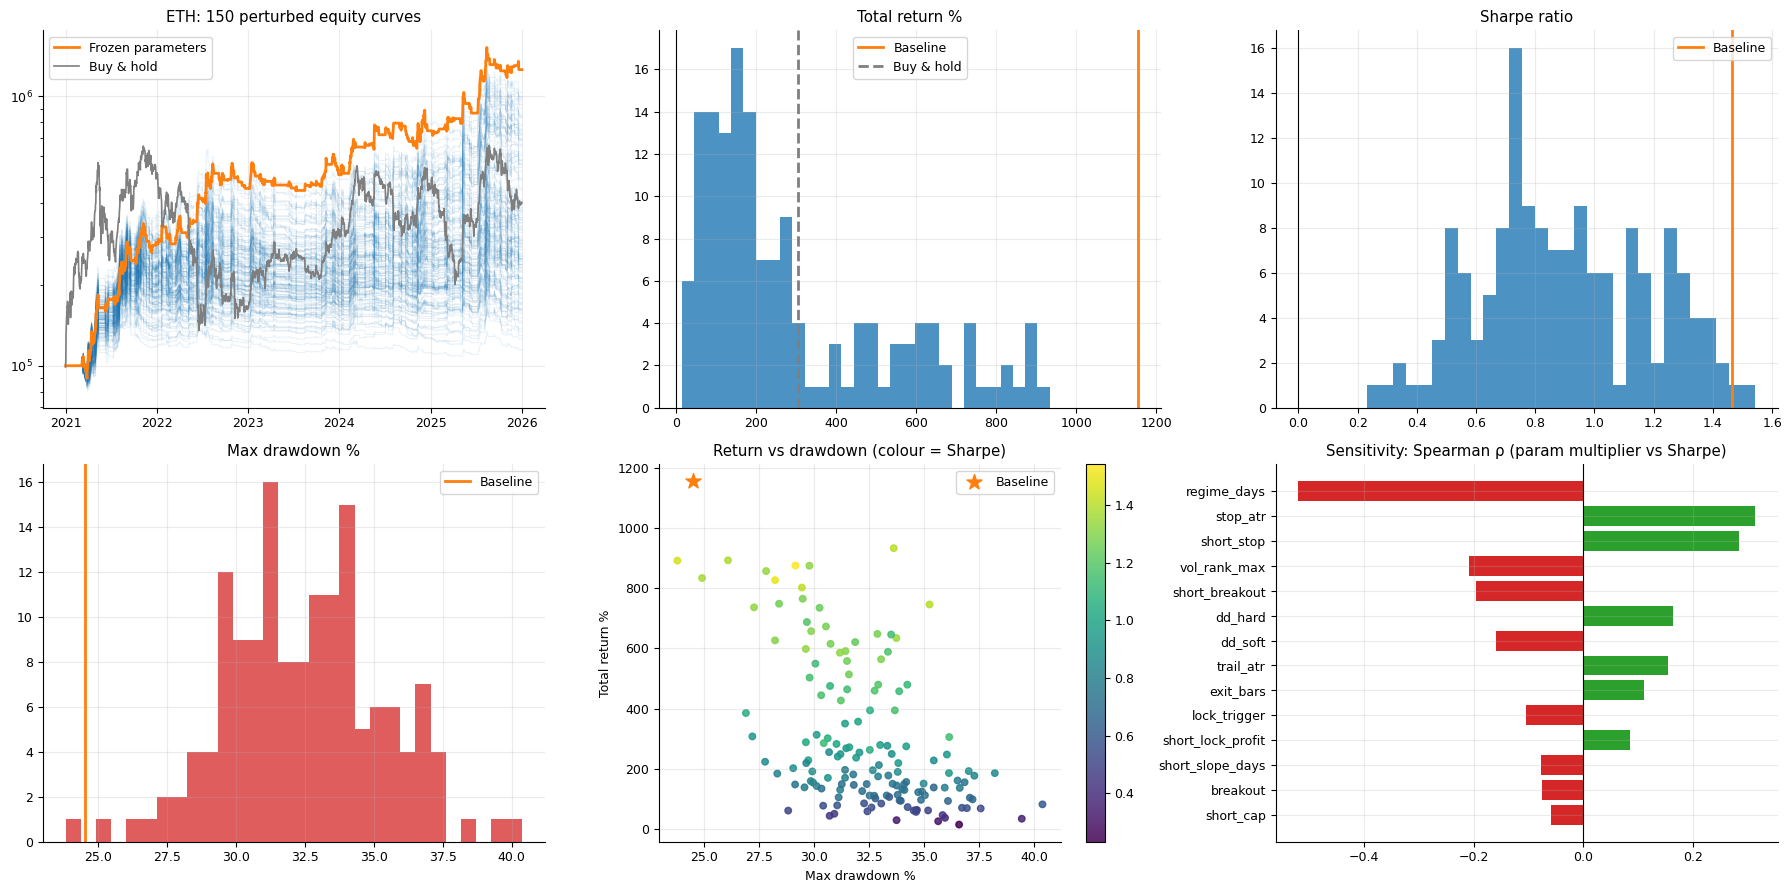

In [9]:
for a, s in SPEC.items():
    P = PARAM[a]; ok = P["df"][P["df"].kind == "perturbed"]; base = P["base"]
    bh_ret = equity_metrics(s["bh"])["total_return_pct"]
    fig, ax = plt.subplots(2, 3, figsize=(18, 9))
    for i, c in P["curves"].items():
        if i: ax[0, 0].plot(c.index, c.values, color=C_STRAT, alpha=.10, lw=.7)
    ax[0, 0].plot(P["curves"][0], color=C_BASE, lw=2, label="Frozen parameters")
    ax[0, 0].plot(s["bh"].resample("1D").last(), color=C_BH, lw=1.2, label="Buy & hold")
    ax[0, 0].set_yscale("log"); ax[0, 0].set_title(f"{a}: {len(ok)} perturbed equity curves"); ax[0, 0].legend()

    ax[0, 1].hist(ok.total_return_pct, bins=30, color=C_STRAT, alpha=.8)
    ax[0, 1].axvline(base["total_return_pct"], color=C_BASE, lw=2, label="Baseline"); ax[0, 1].axvline(bh_ret, color=C_BH, lw=2, ls="--", label="Buy & hold")
    ax[0, 1].axvline(0, color="k", lw=.8); ax[0, 1].set_title("Total return %"); ax[0, 1].legend()

    ax[0, 2].hist(ok.sharpe, bins=30, color=C_STRAT, alpha=.8)
    ax[0, 2].axvline(base["sharpe"], color=C_BASE, lw=2, label="Baseline"); ax[0, 2].axvline(0, color="k", lw=.8)
    ax[0, 2].set_title("Sharpe ratio"); ax[0, 2].legend()

    ax[1, 0].hist(ok.max_dd_pct, bins=30, color=C_BAD, alpha=.75)
    ax[1, 0].axvline(base["max_dd_pct"], color=C_BASE, lw=2, label="Baseline"); ax[1, 0].set_title("Max drawdown %"); ax[1, 0].legend()

    sc = ax[1, 1].scatter(ok.max_dd_pct, ok.total_return_pct, c=ok.sharpe, cmap="viridis", s=22, alpha=.85)
    ax[1, 1].scatter(base["max_dd_pct"], base["total_return_pct"], color=C_BASE, s=130, marker="*", label="Baseline", zorder=5)
    ax[1, 1].set_xlabel("Max drawdown %"); ax[1, 1].set_ylabel("Total return %"); ax[1, 1].set_title("Return vs drawdown (colour = Sharpe)")
    plt.colorbar(sc, ax=ax[1, 1]); ax[1, 1].legend()

    xc = [c for c in ok.columns if c.startswith("x_") and ok[c].nunique() > 3]
    sens = pd.Series({c[2:]: spearmanr(ok[c], ok.sharpe)[0] for c in xc}).dropna()
    sens = sens.reindex(sens.abs().sort_values().index).tail(14)
    ax[1, 2].barh(sens.index, sens.values, color=np.where(sens.values > 0, "#2ca02c", C_BAD))
    ax[1, 2].axvline(0, color="k", lw=.8); ax[1, 2].set_title("Sensitivity: Spearman ρ (param multiplier vs Sharpe)")
    plt.tight_layout(); plt.show()

**Reading Part B**
* A robust strategy has a histogram that is tightly bunched around the baseline with a high `% runs profitable`. A baseline far to the right of the whole cloud means the frozen parameters were picked on a lucky peak.
* The sensitivity bars tell you *which* parameters matter: long bars = the result depends strongly on getting that parameter exactly right.

---
## Part C — Synthetic market test
Brand-new 15-min OHLCV paths (same schema as your CSVs, so the **unmodified** strategy code runs on them). Each path uses Student-t shocks (fat tails), stochastic volatility and OHLC wicks; volatility is scaled to each asset's own historical volatility.

| Scenario | What it simulates |
|---|---|
| `trend_bull` | persistent strong up-drift (~+90 %/yr log-drift) with ordinary pullbacks |
| `momentum_mild` | weak average drift but slowly-changing trends (positive autocorrelation of returns) |
| `bubble_burst` | accelerating parabolic run-up (typically ~10×) → blow-off top → crash with jump-downs (typically −80 %) → grinding bear |
| `chop_low_vol` | mean-reverting range, no drift, ~half normal volatility |

**Caveat:** the synthetic shocks are independent, so they contain none of the real-market microstructure (intraday momentum, volume-driven breakouts) that a breakout system may exploit. Treat the results as *regime stress-tests*, not as forecasts.

Paths with the same index use the same random shocks in all scenarios and both assets (common random numbers), so differences come from the regime, not luck.

In [10]:
SCENARIOS = ["trend_bull", "momentum_mild", "bubble_burst", "chop_low_vol"]
BARS_PER_DAY = 96
DT = 1 / (365 * BARS_PER_DAY)

def scenario_profile(kind, n):
    x = np.linspace(0, 1, n)
    if kind == "trend_bull":
        return dict(mu=np.full(n, 0.90), vm=np.full(n, 0.90), drift_sd=0.9, drift_tau=60, vov=0.45)
    if kind == "momentum_mild":
        return dict(mu=np.full(n, 0.20), vm=np.full(n, 1.00), drift_sd=0.9, drift_tau=25, vov=0.45)
    if kind == "bubble_burst":
        mu = np.interp(x, [0, .45, .50, .51, .58, .62, 1.0], [0.5, 2.8, 0.3, -2.0, -2.0, -0.10, 0.30])
        vm = np.interp(x, [0, .45, .50, .51, .60, .70, 1.0], [0.8, 1.1, 1.3, 1.5, 1.3, 1.0, 0.7])
        crash = (x >= .51) & (x <= .58)
        return dict(mu=mu, vm=vm, drift_sd=0.4, drift_tau=20, vov=0.45,
                    jump_rate=np.where(crash, 5 / max(crash.sum(), 1), 0.0), jump_mu=-0.05, jump_sd=0.025)
    if kind == "chop_low_vol":
        return dict(mu=np.zeros(n), vm=np.full(n, 0.55), drift_sd=0.0, drift_tau=30, vov=0.15, revert_halflife_days=25)
    raise ValueError(kind)

def _ou(rng, n, tau_days, sd):
    """Stationary mean-zero Ornstein-Uhlenbeck series with std `sd` and time-constant `tau_days` (per-bar)."""
    if sd == 0: return np.zeros(n)
    a = np.exp(-1 / (tau_days * BARS_PER_DAY))
    return lfilter([1.0], [1.0, -a], rng.normal(0, sd * np.sqrt(1 - a * a), n))

def make_synthetic(kind, seed, p0, base_vol, med_volume, days=SYNTH_DAYS, start="2021-01-01"):
    """Return a 15-min OHLCV DataFrame in exactly the format the strategy files expect."""
    rng = np.random.default_rng(seed); n = days * BARS_PER_DAY
    P = scenario_profile(kind, n)
    sig = base_vol * P["vm"] * np.exp(_ou(rng, n, 10, P["vov"]) - .5 * P["vov"] ** 2)
    df_t = 5; eps = rng.standard_t(df_t, n) * np.sqrt((df_t - 2) / df_t)
    sb = sig * np.sqrt(DT)
    if "revert_halflife_days" in P:
        a = np.exp(-np.log(2) / (P["revert_halflife_days"] * BARS_PER_DAY))
        logp = np.log(p0) + lfilter([1.0], [1.0, -a], sb * eps)
    else:
        mu = P["mu"] + _ou(rng, n, P["drift_tau"], P["drift_sd"])
        r = (mu - .5 * sig ** 2) * DT + sb * eps
        if "jump_rate" in P:
            jumps = rng.random(n) < P["jump_rate"]
            r = r + jumps * rng.normal(P["jump_mu"], P["jump_sd"], n)
        logp = np.log(p0) + np.cumsum(np.clip(r, -.4, .4))
    c = np.exp(logp); o = np.r_[p0, c[:-1]]
    wick = .48 * sb
    h = np.maximum(o, c) * np.exp(wick * np.abs(rng.normal(size=n)))
    l = np.minimum(o, c) * np.exp(-wick * np.abs(rng.normal(size=n)))
    vol = med_volume * np.exp(rng.normal(0, .5, n)) * (1 + np.abs(np.log(c / o)) / sb) / 1.8
    idx = pd.date_range(start, periods=n, freq="15min", tz="UTC", name="timestamp")
    d = pd.DataFrame(dict(open=o, high=h, low=l, close=c, volume=vol), index=idx)
    d["tradable"] = True
    return d

for a, s in SPEC.items():
    daily = s["d"].close.resample("1D").last()
    s["calib"] = dict(p0=float(s["d"].open.iloc[0]), base_vol=float(np.log(daily).diff().std() * np.sqrt(365)),
                      med_volume=float(s["d"].volume.median()))
    print(a, {k: round(v, 3) for k, v in s["calib"].items()})

BTC {'p0': 28923.63, 'base_vol': 0.586, 'med_volume': 348.944}
ETH {'p0': 736.42, 'base_vol': 0.791, 'med_volume': 3727.393}


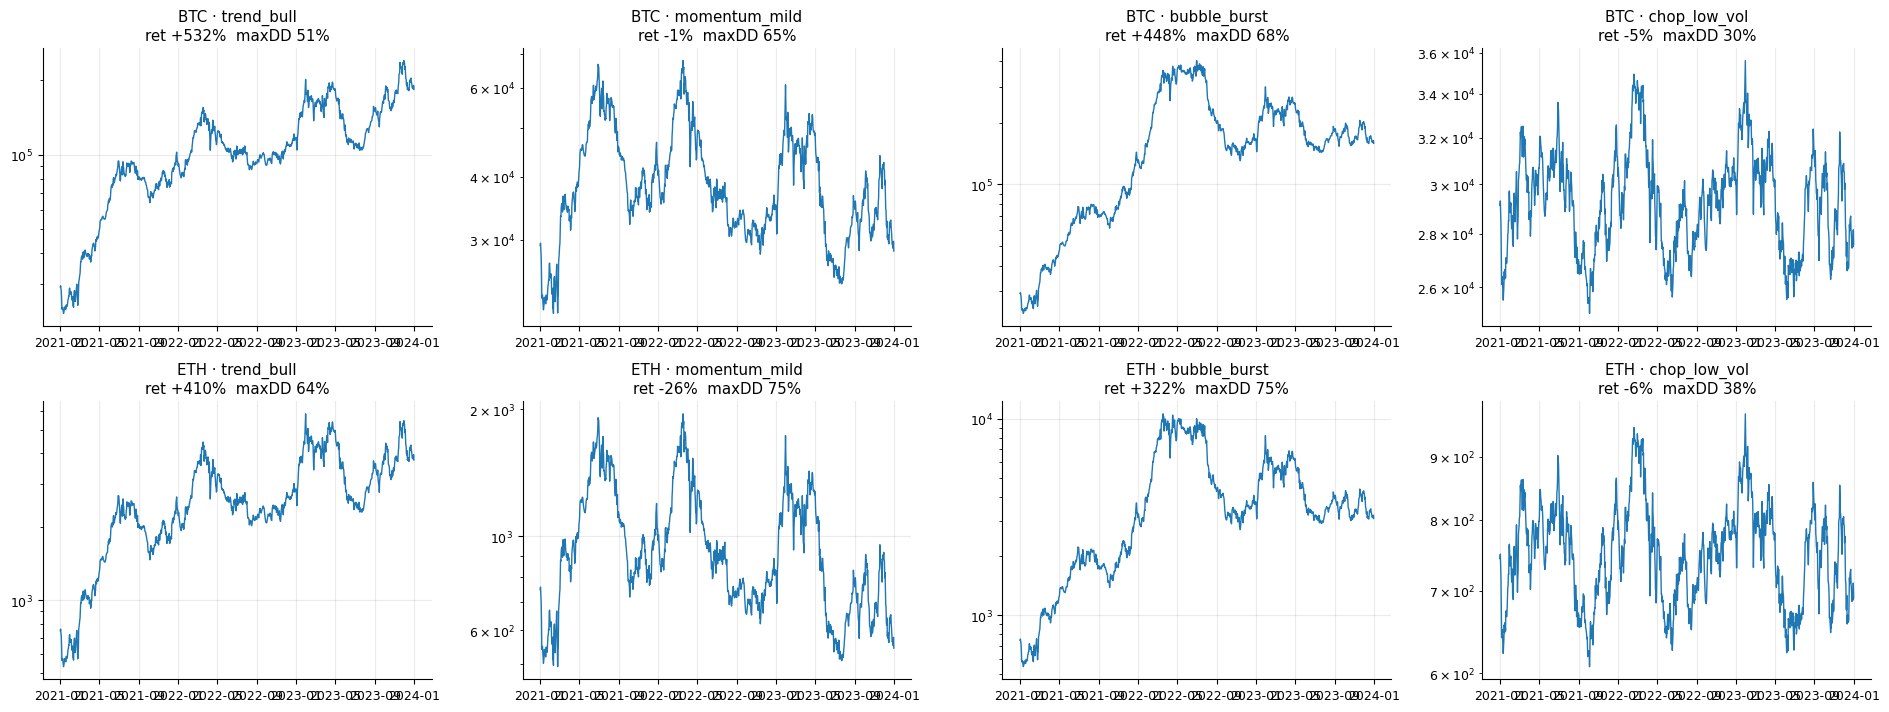

Sanity check – synthetic paths vs. the real history (vol, fat tails and candle-wick size should be in the same ballpark):


,total_return_pct,max_dd_pct,ann_vol_pct,daily_kurtosis,hl_to_abs_ret
BTC REAL history,203.03,77.23,58.56,3.79,2.04
BTC trend_bull,532.02,51.06,56.91,2.29,2.05
BTC momentum_mild,-1.39,65.45,63.23,2.31,2.05
BTC bubble_burst,448.23,68.36,62.55,2.05,2.05
BTC chop_low_vol,-4.59,29.90,31.57,0.57,2.05
ETH REAL history,303.53,81.46,79.13,5.44,2.04
ETH trend_bull,410.25,63.66,76.71,2.32,2.05
ETH momentum_mild,-26.13,75.48,85.25,2.33,2.05
ETH bubble_burst,321.63,75.30,84.09,2.09,2.05
ETH chop_low_vol,-6.15,38.12,42.66,0.57,2.05


In [11]:
def path_summary(d):
    daily = d.close.resample("1D").last(); lr = np.log(daily).diff().dropna()
    return dict(total_return_pct=100 * (d.close.iloc[-1] / d.open.iloc[0] - 1),
                max_dd_pct=100 * (1 - d.close / d.close.cummax()).max(),
                ann_vol_pct=100 * lr.std() * np.sqrt(365), daily_kurtosis=lr.kurt(),
                hl_to_abs_ret=((d.high - d.low) / d.open).mean() / (d.close / d.open - 1).abs().mean())

fig, axes = plt.subplots(len(SPEC), 4, figsize=(19, 3.6 * len(SPEC)), squeeze=False)
rows = {}
for j, (a, s) in enumerate(SPEC.items()):
    real = s["d"]; rows[f"{a} REAL history"] = path_summary(real)
    for i, k in enumerate(SCENARIOS):
        d = make_synthetic(k, SEED, **s["calib"]); rows[f"{a} {k}"] = path_summary(d)
        ax = axes[j, i]; ax.plot(d.close.resample("1D").last(), color=C_STRAT, lw=1); ax.set_yscale("log")
        ax.set_title(f"{a} · {k}\nret {rows[f'{a} {k}']['total_return_pct']:+.0f}%  maxDD {rows[f'{a} {k}']['max_dd_pct']:.0f}%")
plt.tight_layout(); plt.show()
print("Sanity check – synthetic paths vs. the real history (vol, fat tails and candle-wick size should be in the same ballpark):")
display(pd.DataFrame(rows).T.round(2))

In [12]:
SYN_ROWS, SYN_EX = [], {}
for a, s in SPEC.items():
    t0 = time.time()
    for k in SCENARIOS:
        for i in range(N_SYNTH_PATHS):
            d = make_synthetic(k, SEED + i, **s["calib"])
            bh = bh_curve(d, d.index); b = equity_metrics(bh)
            try:
                path, fills, tr, audit = s["mod"].run(d, s["cfg"], features=s["mod"].Features(d))
                m = equity_metrics(path.equity)
                row = dict(asset=a, scenario=k, path=i, **m, trades=len(tr), exposure_pct=100 * path.exposure.mean(),
                           bh_return_pct=b["total_return_pct"], bh_max_dd_pct=b["max_dd_pct"], bh_sharpe=b["sharpe"],
                           gross_breach=audit["gap_cap_breaches"] + audit["intrabar_cap_breaches"], failed=False)
                if i == 0: SYN_EX[(a, k)] = (d, path, tr, bh)
            except Exception as e:
                row = dict(asset=a, scenario=k, path=i, failed=True, error=str(e)[:80], bh_return_pct=b["total_return_pct"],
                           bh_max_dd_pct=b["max_dd_pct"], bh_sharpe=b["sharpe"])
            SYN_ROWS.append(row)
        print(f"  {a} · {k}: {N_SYNTH_PATHS} paths done  (cumulative {time.time()-t0:.0f}s)")
SYN = pd.DataFrame(SYN_ROWS)
SYN["excess_return_pct"] = SYN.total_return_pct - SYN.bh_return_pct
SYN.to_csv(OUT_DIR / "C_synthetic_runs.csv", index=False)
print("\nfailed runs:", int(SYN.failed.sum()), "| runs with >1x gross-exposure breach:", int((SYN.get("gross_breach", pd.Series(0)).fillna(0) > 0).sum()))

  BTC · trend_bull: 20 paths done  (cumulative 3s)


  BTC · momentum_mild: 20 paths done  (cumulative 6s)


  BTC · bubble_burst: 20 paths done  (cumulative 9s)


  BTC · chop_low_vol: 20 paths done  (cumulative 12s)


  ETH · trend_bull: 20 paths done  (cumulative 5s)


  ETH · momentum_mild: 20 paths done  (cumulative 9s)


  ETH · bubble_burst: 20 paths done  (cumulative 14s)


  ETH · chop_low_vol: 20 paths done  (cumulative 19s)

failed runs: 0 | runs with >1x gross-exposure breach: 0


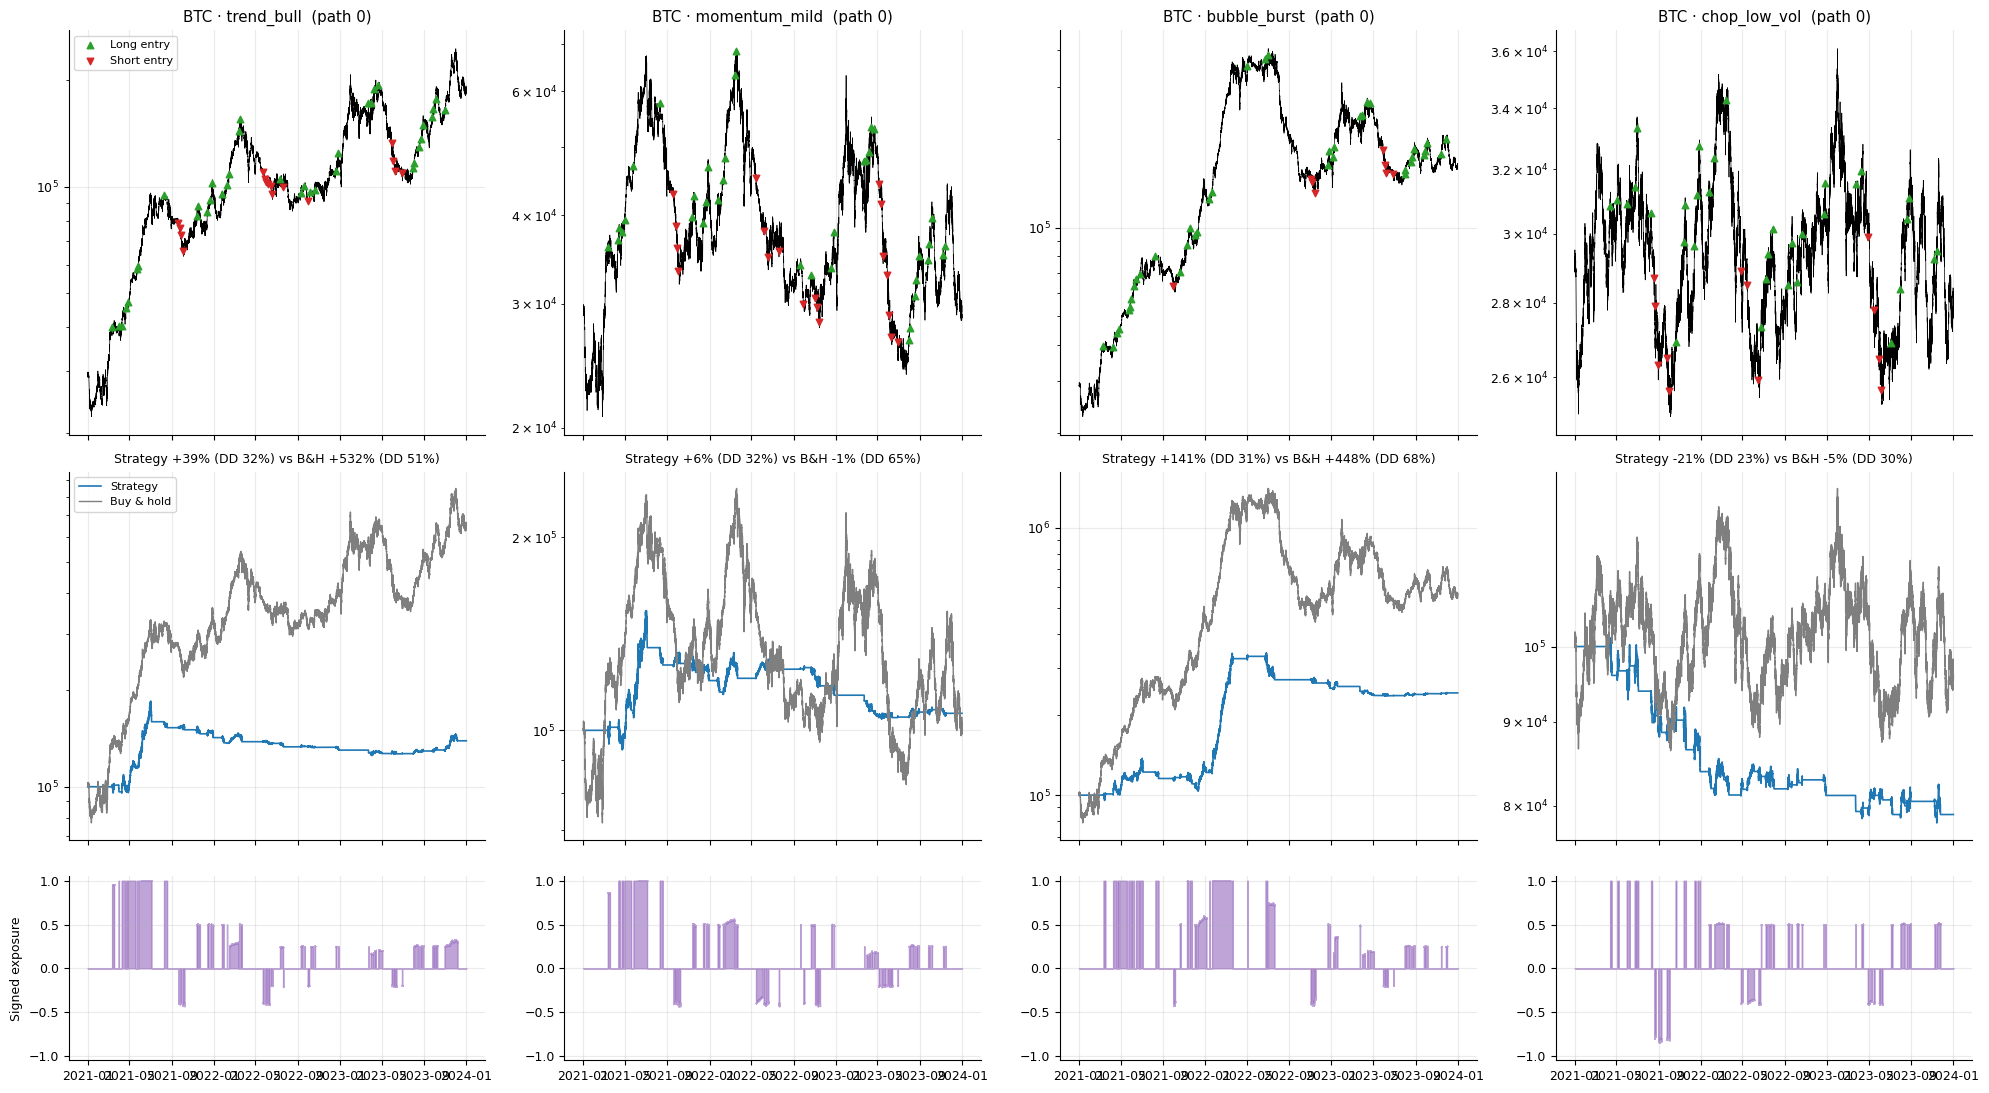

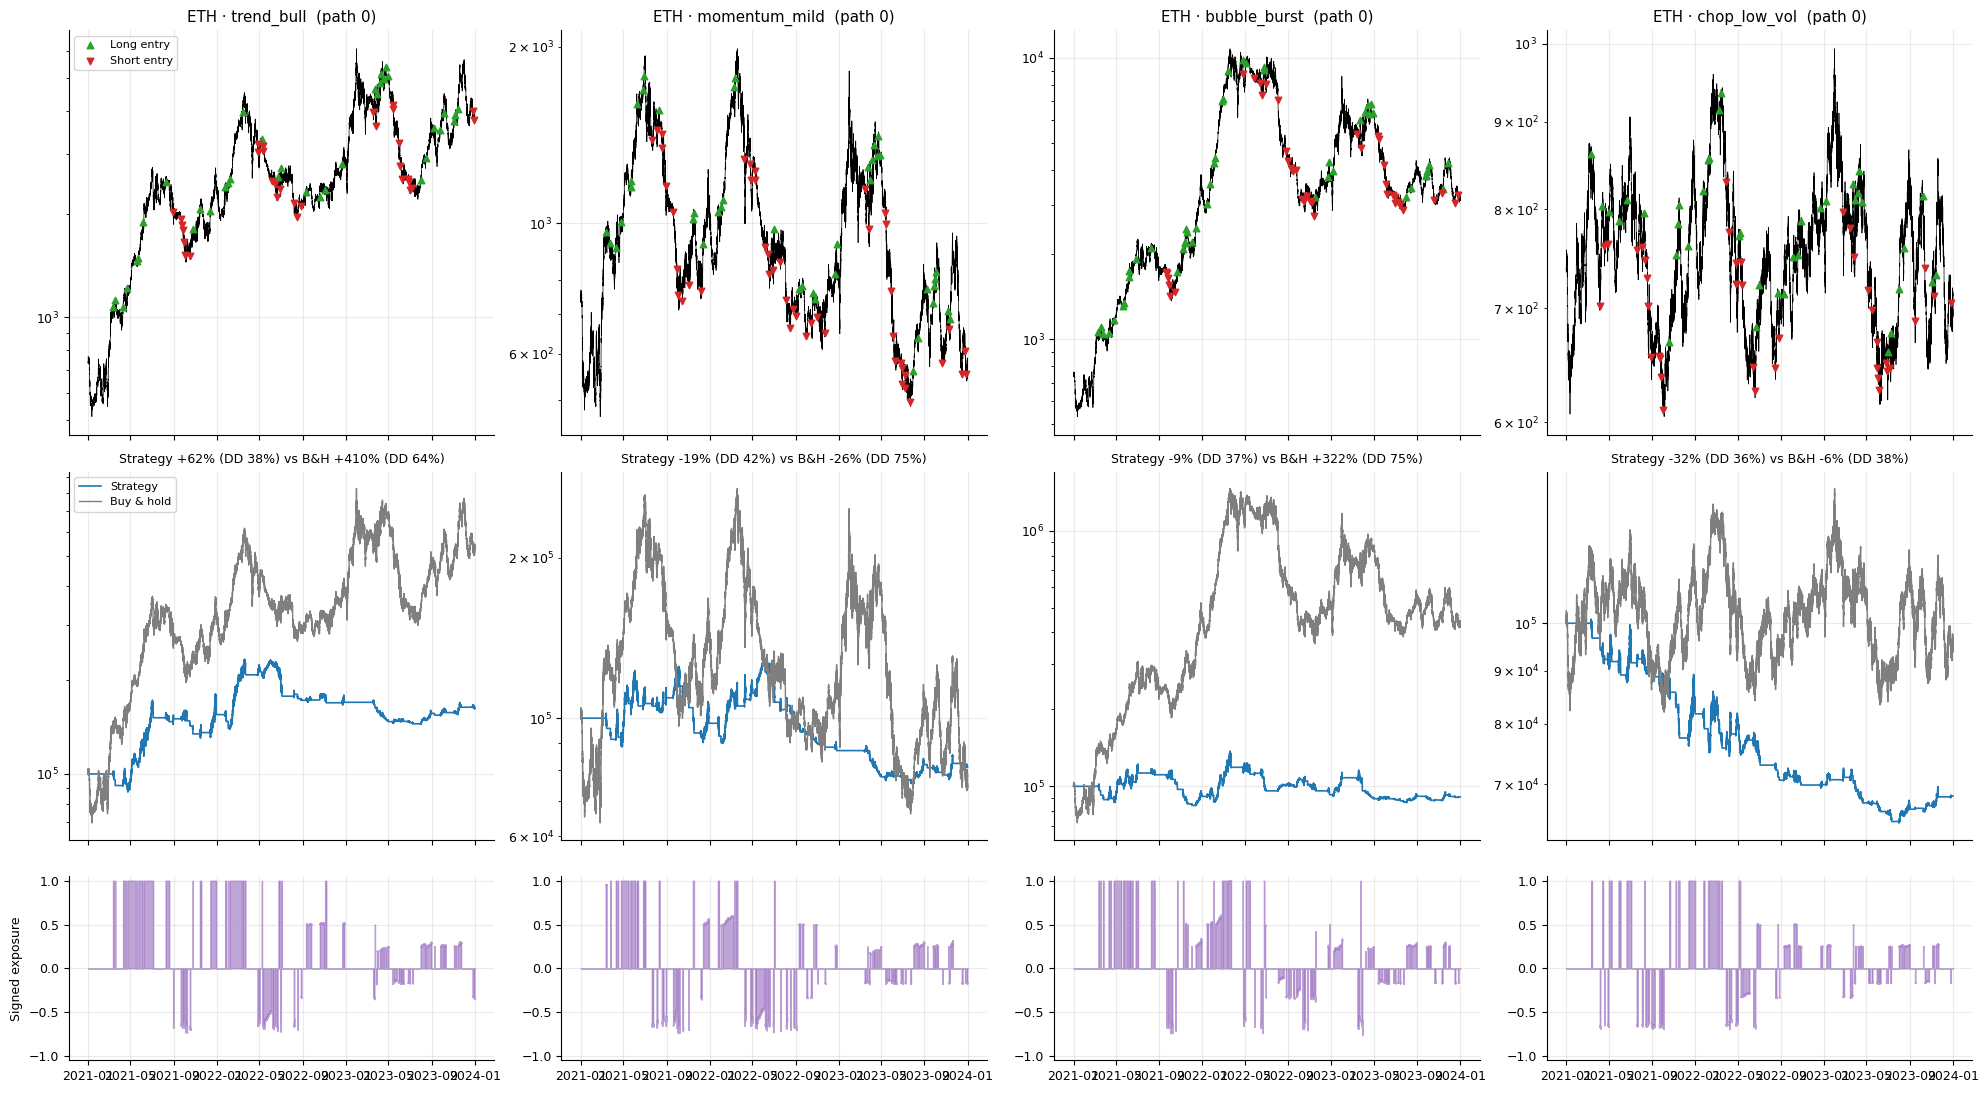

In [13]:
for a, s in SPEC.items():
    fig, ax = plt.subplots(3, 4, figsize=(20, 11), sharex="col", gridspec_kw={"height_ratios": [2.2, 2, 1]})
    for j, k in enumerate(SCENARIOS):
        if (a, k) not in SYN_EX: continue
        d, path, tr, bh = SYN_EX[(a, k)]
        ax[0, j].plot(d.close, color="black", lw=.5); ax[0, j].set_yscale("log"); ax[0, j].set_title(f"{a} · {k}  (path 0)")
        for side, col, mk, nm in ((1, "tab:green", "^", "Long entry"), (-1, "tab:red", "v", "Short entry")):
            t = tr[tr.direction == side]
            if len(t): ax[0, j].scatter(t.entry_time, d.open.reindex(t.entry_time).values, s=22, color=col, marker=mk, label=nm, zorder=3)
        if j == 0: ax[0, j].legend(loc="upper left", fontsize=8)
        ax[1, j].plot(path.equity, color=C_STRAT, lw=1.2, label="Strategy"); ax[1, j].plot(bh, color=C_BH, lw=1, label="Buy & hold")
        ax[1, j].set_yscale("log")
        sm, bm = equity_metrics(path.equity), equity_metrics(bh)
        ax[1, j].set_title(f"Strategy {sm['total_return_pct']:+.0f}% (DD {sm['max_dd_pct']:.0f}%) vs B&H {bm['total_return_pct']:+.0f}% (DD {bm['max_dd_pct']:.0f}%)", fontsize=9)
        if j == 0: ax[1, j].legend(fontsize=8)
        ax[2, j].fill_between(path.index, path.signed_exposure, 0, step="post", color="tab:purple", alpha=.6); ax[2, j].set_ylim(-1.05, 1.05)
        if j == 0: ax[2, j].set_ylabel("Signed exposure")
    plt.tight_layout(); plt.show()

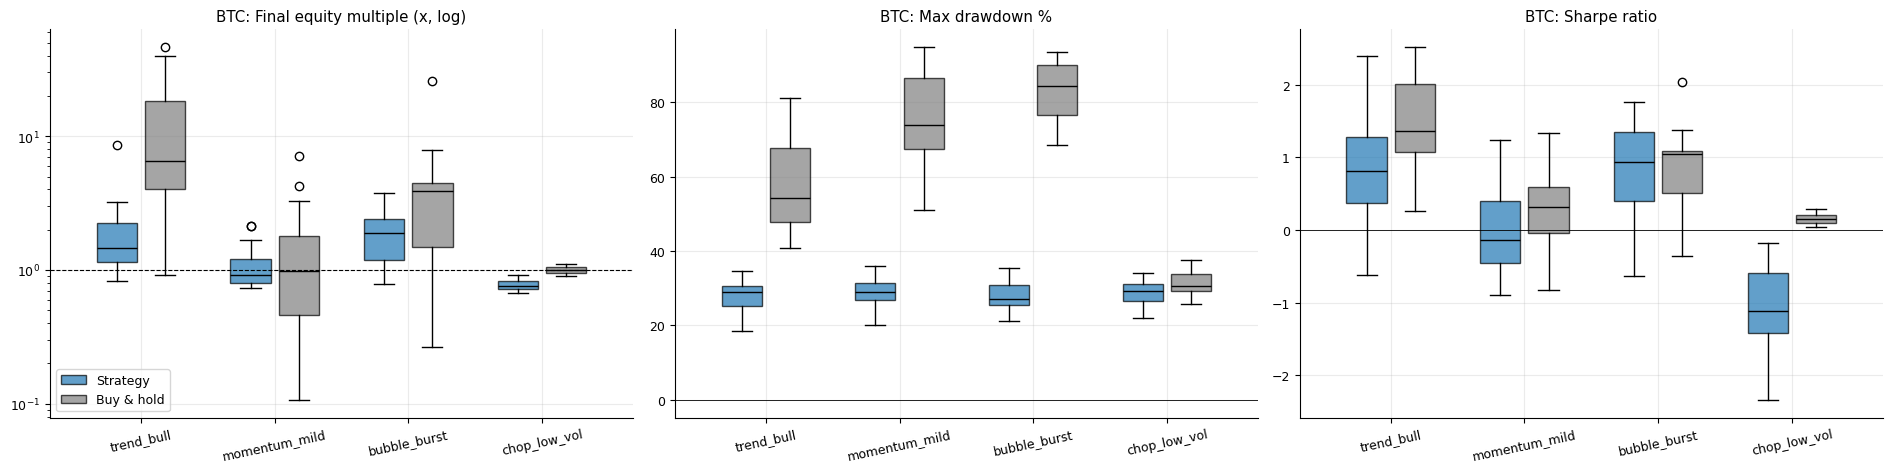

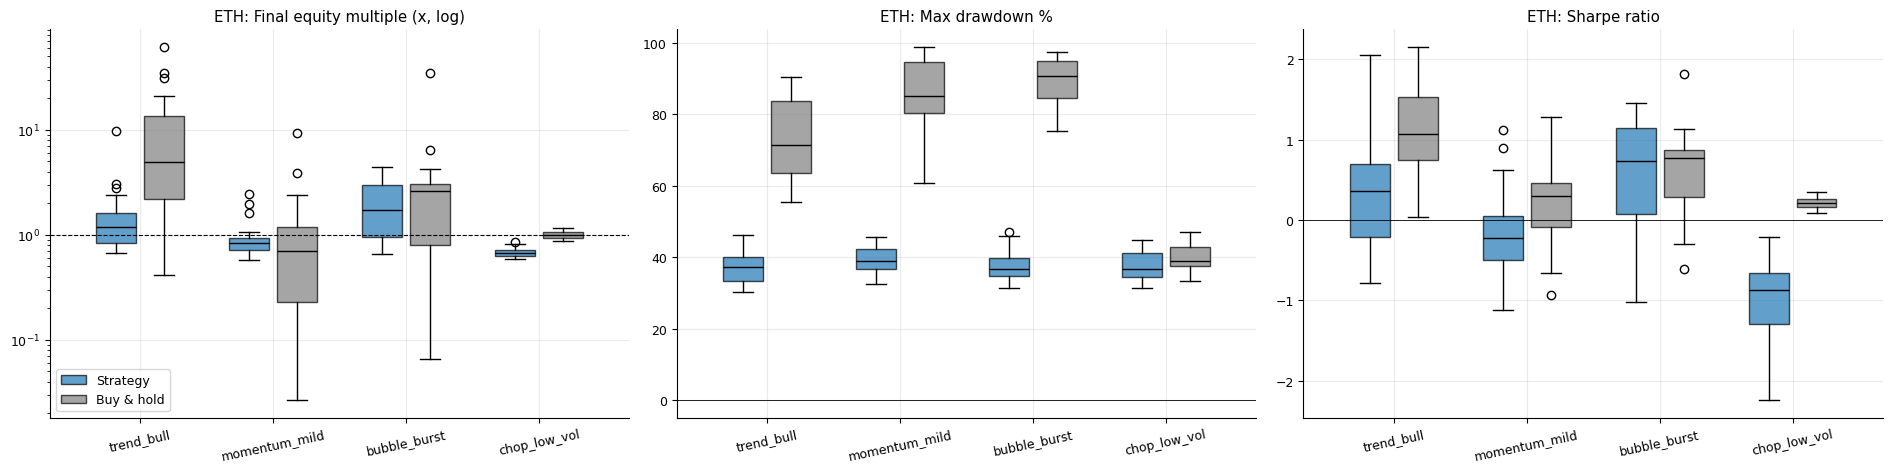

In [14]:
ok = SYN[~SYN.failed]
for a in SPEC:
    sub = ok[ok.asset == a]
    fig, ax = plt.subplots(1, 3, figsize=(19, 4.8)); pos = np.arange(len(SCENARIOS))
    panels = [("Final equity multiple (x, log)", lambda d: 1 + d.total_return_pct / 100, lambda d: 1 + d.bh_return_pct / 100, True),
              ("Max drawdown %", lambda d: d.max_dd_pct, lambda d: d.bh_max_dd_pct, False),
              ("Sharpe ratio", lambda d: d.sharpe, lambda d: d.bh_sharpe, False)]
    for axi, (title, fs, fb, logy) in zip(ax, panels):
        data_s = [fs(sub[sub.scenario == k]).values for k in SCENARIOS]; data_b = [fb(sub[sub.scenario == k]).values for k in SCENARIOS]
        b1 = axi.boxplot(data_s, positions=pos - .18, widths=.3, patch_artist=True, showfliers=True)
        b2 = axi.boxplot(data_b, positions=pos + .18, widths=.3, patch_artist=True, showfliers=True)
        for bp, col in ((b1, C_STRAT), (b2, C_BH)):
            for p in bp["boxes"]: p.set_facecolor(col); p.set_alpha(.7)
            for m in bp["medians"]: m.set_color("black")
        if logy: axi.set_yscale("log"); axi.axhline(1, color="k", lw=.8, ls="--")
        else: axi.axhline(0, color="k", lw=.6)
        axi.set_xticks(pos); axi.set_xticklabels(SCENARIOS, rotation=12); axi.set_title(f"{a}: {title}")
    ax[0].legend([b1["boxes"][0], b2["boxes"][0]], ["Strategy", "Buy & hold"], loc="lower left")
    plt.tight_layout(); plt.show()

In [15]:
g = ok.groupby(["asset", "scenario"])
score = pd.DataFrame({
    "paths": g.size(),
    "median strat return %": g.total_return_pct.median(), "median B&H return %": g.bh_return_pct.median(),
    "% paths profitable": g.apply(lambda x: 100 * (x.total_return_pct > 0).mean()),
    "% paths beating B&H": g.apply(lambda x: 100 * (x.total_return_pct > x.bh_return_pct).mean()),
    "5th pct strat return %": g.total_return_pct.quantile(.05),
    "median strat maxDD %": g.max_dd_pct.median(), "median B&H maxDD %": g.bh_max_dd_pct.median(),
    "95th pct strat maxDD %": g.max_dd_pct.quantile(.95),
    "median Sharpe": g.sharpe.median(), "median B&H Sharpe": g.bh_sharpe.median(),
    "median trades": g.trades.median(), "median exposure %": g.exposure_pct.median(),
}).reindex(pd.MultiIndex.from_product([list(SPEC), SCENARIOS], names=["asset", "scenario"]))
display(score.round(1))
score.to_csv(OUT_DIR / "C_synthetic_scorecard.csv")

paths  median strat return %  median B&H return %  \
asset scenario                                                           
BTC   trend_bull        20                   44.8                548.3   
      momentum_mild     20                   -8.8                 -1.0   
      bubble_burst      20                   87.4                291.4   
      chop_low_vol      20                  -24.8                 -0.8   
ETH   trend_bull        20                   18.9                398.1   
      momentum_mild     20                  -16.9                -30.5   
      bubble_burst      20                   70.5                158.9   
      chop_low_vol      20                  -32.4                 -1.1   

                     % paths profitable  % paths beating B&H  \
asset scenario                                                 
BTC   trend_bull                   85.0                  5.0   
      momentum_mild                40.0                 60.0   
      bubble_burst                 90.0                 35.0   
      chop_low_vol                  0.0                  0.0   
ETH   trend_bull                   65.0                 20.0   
      momentum_mild                20.0                 65.0   
      bubble_burst                 65.0                 55.0   
      chop_low_vol                  0.0                  0.0   

                     5th pct strat return %  median strat maxDD %  \
asset scenario                                                      
BTC   trend_bull                      -16.2                  29.0   
      momentum_mild                   -26.1                  28.9   
      bubble_burst                     -2.7                  27.1   
      chop_low_vol                    -31.0                  29.2   
ETH   trend_bull                      -30.4                  37.3   
      momentum_mild                   -34.2                  39.0   
      bubble_burst                    -34.0                  36.8   
      chop_low_vol                    -40.7                  36.7   

                     median B&H maxDD %  95th pct strat maxDD %  \
asset scenario                                                    
BTC   trend_bull                   54.3                    33.6   
      momentum_mild                73.9                    33.7   
      bubble_burst                 84.3                    33.6   
      chop_low_vol                 30.6                    33.5   
ETH   trend_bull                   71.5                    41.9   
      momentum_mild                85.0                    45.7   
      bubble_burst                 90.7                    46.0   
      chop_low_vol                 38.9                    43.3   

                     median Sharpe  median B&H Sharpe  median trades  \
asset scenario                                                         
BTC   trend_bull               0.8                1.4           57.0   
      momentum_mild           -0.1                0.3           61.0   
      bubble_burst             0.9                1.0           57.5   
      chop_low_vol            -1.1                0.2           59.0   
ETH   trend_bull               0.4                1.1           82.0   
      momentum_mild           -0.2                0.3           92.5   
      bubble_burst             0.7                0.8           85.5   
      chop_low_vol            -0.9                0.2           85.5   

                     median exposure %  
asset scenario                          
BTC   trend_bull                  20.8  
      momentum_mild               12.5  
      bubble_burst                18.6  
      chop_low_vol                11.1  
ETH   trend_bull                  17.6  
      momentum_mild               13.3  
      bubble_burst                19.3  
      chop_low_vol                13.2

---
## Final — one-page scorecard

In [16]:
final = {}
for a, s in SPEC.items():
    P = PARAM[a]["summary"]; t = tables[a]
    row = {"historical return %": baseline.loc[f"{a} strategy", "total_return_pct"],
           "historical max DD %": baseline.loc[f"{a} strategy", "max_dd_pct"],
           "A · bootstrap P(loss) %": t.loc["Bootstrap", "prob_loss"],
           "A · bootstrap 5th-pct return %": t.loc["Bootstrap", "p5_ret"],
           "A · shuffle 95th-pct DD %": t.loc["Shuffle", "p95_dd"],
           "B · % perturbed runs profitable": P["% runs profitable"],
           "B · median perturbed Sharpe / baseline": P["median Sharpe"] / P["baseline Sharpe"] if P["baseline Sharpe"] else np.nan,
           "B · 95th-pct perturbed DD %": P["95th pct max DD %"]}
    for k in SCENARIOS:
        row[f"C · {k}: % paths profitable"] = score.loc[(a, k), "% paths profitable"]
        row[f"C · {k}: median ret %"] = score.loc[(a, k), "median strat return %"]
        row[f"C · {k}: median maxDD %"] = score.loc[(a, k), "median strat maxDD %"]
    final[a] = row
final = pd.DataFrame(final)
display(final.round(1))
final.to_csv(OUT_DIR / "final_scorecard.csv")
print(f"All tables were also saved as CSV in: {OUT_DIR.resolve()}")

,BTC,ETH
historical return %,733.0,1154.6
historical max DD %,23.6,24.5
A · bootstrap P(loss) %,0.0,0.2
A · bootstrap 5th-pct return %,177.2,170.5
A · shuffle 95th-pct DD %,18.8,40.2
B · % perturbed runs profitable,100.0,100.0
B · median perturbed Sharpe / baseline,0.6,0.6
B · 95th-pct perturbed DD %,31.6,37.0
C · trend_bull: % paths profitable,85.0,65.0
C · trend_bull: median ret %,44.8,18.9


All tables were also saved as CSV in: /home/claude/nb/mc_results
